In [1]:
from pyinaturalist import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

In [2]:
import time

PARENT_TAXON_ID = 47224 

top_species = []

# Fetch 80 results by paginating through 2 pages of 40 items each
for page in range(1, 3):
    response = get_observation_species_counts(
        taxon_id=PARENT_TAXON_ID,
        hrank='species',    
        per_page=40,      
        place_id=42,
        page=page
    )
    

    top_species.extend(response.get('results', []))
    time.sleep(1) 


In [3]:
taxa = {}
for i, item in enumerate(top_species, 1):
    taxon_info = item['taxon']
    taxa[taxon_info['id']] = taxon_info['name']
    
taxon_ids = [key for key, value in taxa.items()]
print(taxon_ids)

[48662, 60551, 1455248, 81559, 55626, 60607, 58523, 58525, 52925, 1456562, 1081329, 49133, 133631, 58555, 54064, 58532, 82792, 68244, 58478, 48505, 58564, 58481, 58603, 58579, 56832, 122281, 48549, 58531, 68264, 50931, 198812, 48548, 1363161, 58586, 58475, 58514, 50071, 58606, 62978, 58539, 49972, 1038408, 1081323, 83086, 132227, 1456448, 50340, 1363179, 58556, 58578, 85024, 1456585, 69145, 58561, 67439, 58587, 58484, 81729, 48550, 58479, 58506, 58576, 127490, 58509, 1650173, 58541, 198801, 58580, 1456600, 1360291, 1456640, 143664, 58511, 126118, 58473, 198804, 58474, 84239, 58550, 82793]


In [4]:
# Convert months to approximate middle-of-month day of year
month_days = np.array([
    15,   # January
    46,   # February
    74,   # March
    105,  # April
    135,  # May
    166,  # June
    196,  # July
    227,  # August
    258,  # September
    288,  # October
    319,  # November
    349   # December
])

days = np.arange(1, 366)

In [5]:
def get_curve(taxon_id):
    histogram = get_observation_histogram(
        taxon_id=taxon_id, 
        place_id=42, 
        quality_grade='research'
    )
    
    months = np.array(list(histogram.keys()))
    observations = np.array(list(histogram.values()))
    
    interpolator = PchipInterpolator(month_days, observations)
    daily_observations = interpolator(days)
    
    # Normalize to maximum = 1
    daily_normalized = daily_observations / daily_observations.max()
    
    return daily_normalized

In [6]:
phenology = {}
for taxon in taxon_ids:
    phenology[taxon] = get_curve(taxon)
    time.sleep(1) 

# Reverse dict to put species with most observations at the top
phenology = dict(reversed(phenology.items()))

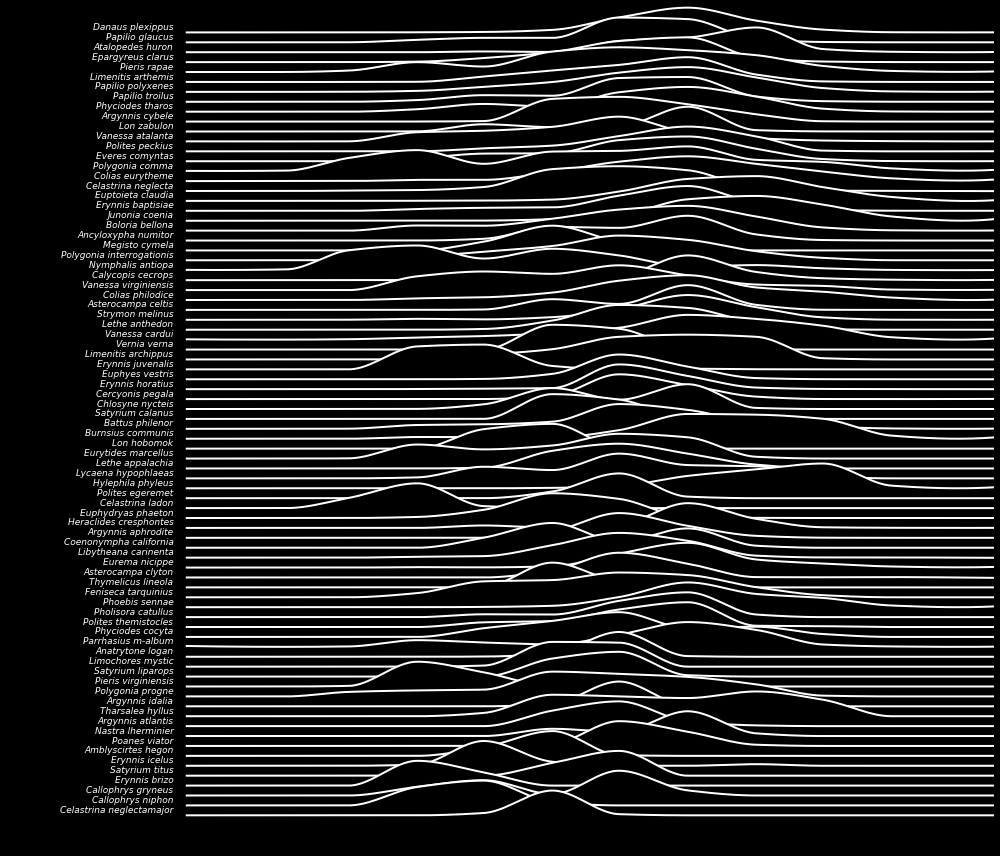

In [8]:
fig, ax = plt.subplots(figsize=(14, 12))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

spacing = 0.4

for i, (taxon, curve) in enumerate(phenology.items()):

    baseline = i * spacing
    y = baseline + curve

    ax.fill_between(
        days,
        y,
        color="black",
        zorder=len(phenology)-i
    )
    
    
    ax.plot(
        days,
        y,
        linewidth=2,
        color="white",
        zorder=len(phenology)-i
    )

    # Species label
    ax.text(
        -5,
        baseline + 0.05,
        taxa[taxon],
        ha="right",
        va="bottom",
        fontsize=9,
        color="white",
        style="italic"
    )


# Formatting
ax.set_xlim(-80, 365)
ax.set_ylim(-0.1, (len(phenology) - 1) * spacing + 1.05)

ax.set_yticks([])

ax.set_xlabel("Day of year")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()